In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import ast

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None) 

In [78]:
data = pd.read_csv('/Users/oguzhanerbil/Documents/Repolarım/food-health-predictor/data/data.csv')

In [79]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69726 entries, 0 to 69725
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   barkod                      69725 non-null  float64
 1   miktar                      56310 non-null  float64
 2   markalar                    67276 non-null  object 
 3   alerjenler                  69726 non-null  object 
 4   eser_miktarlar              69726 non-null  object 
 5   icerik_sayisi               60523 non-null  float64
 6   nutriscore_notu             69654 non-null  object 
 7   nova_grubu                  58965 non-null  float64
 8   yesil_skor_notu             50873 non-null  object 
 9   palmiye_yagi_icermez        56370 non-null  object 
 10  vejetaryen                  53786 non-null  object 
 11  vegan_durumu                60892 non-null  object 
 12  enerji_kcal                 68873 non-null  float64
 13  yag_g                       688

In [80]:
data.describe()

,barkod,miktar,icerik_sayisi,nova_grubu,enerji_kcal,yag_g,doymus_yag_g,karbonhidrat_g,seker_g,lif_g,protein_g,tuz_g,alkol_yuzde,meyve_sebze_baklagil_yuzde
count,6.972500e+04,5.631000e+04,60523.000000,58965.000000,68873.000000,68864.000000,68116.000000,68798.000000,68541.000000,49389.000000,68840.000000,68969.000000,3393.000000,22373.000000
mean,5.901744e+12,1.232567e+08,13.249046,3.122971,265.989764,13.857302,4.546168,26.325415,9.864076,3.230829,7.430862,6.322072,4.946971,14.538270
std,3.863905e+14,2.538643e+10,13.496987,1.142257,425.694753,32.447756,8.365573,28.944037,20.219194,5.048495,9.149482,1355.587310,19.716986,30.472108
min,1.328000e+03,0.000000e+00,1.000000,1.000000,0.000000,-0.880969,-0.126229,0.000000,0.000000,0.000000,0.000000,-0.179539,0.000000,-1.217330
25%,3.256227e+12,5.000000e+01,4.000000,3.000000,77.000000,1.000000,0.200000,4.100000,0.500000,0.400000,1.587302,0.030000,0.000000,0.000000
50%,4.016249e+12,2.000000e+02,10.000000,4.000000,223.000000,5.140000,1.304348,12.941176,3.300000,1.900000,5.800000,0.310000,0.000000,0.000000
75%,5.942326e+12,4.000000e+02,18.000000,4.000000,400.000000,20.000000,5.357143,51.333333,10.500000,4.400000,10.000000,1.000000,0.000000,10.400000
max,1.020304e+17,5.940568e+12,405.000000,4.000000,50700.000000,5856.650000,450.000000,1900.000000,1700.000000,375.000000,800.000000,355942.500000,100.000000,449.400000


In [81]:
data.sample(5)

,barkod,miktar,markalar,alerjenler,eser_miktarlar,icerik_sayisi,nutriscore_notu,nova_grubu,yesil_skor_notu,palmiye_yagi_icermez,vejetaryen,vegan_durumu,enerji_kcal,yag_g,doymus_yag_g,karbonhidrat_g,seker_g,lif_g,protein_g,tuz_g,alkol_yuzde,meyve_sebze_baklagil_yuzde,birim,kategori_listesi,etiketler_listesi
67236,5.012036e+12,NaN,haribo,['Orange'],[],29.0,E,4.0,A,True,False,no,345.0,0.500000,0.10,80.000000,55.000000,NaN,6.300000,0.030000,NaN,3.004444,NaN,"['Snacks', 'Sweet snacks', 'Confectioneries', ...",[]
1866,8.402001e+12,NaN,hacendado,['Milk'],[],20.0,A,4.0,NaN,NaN,True,no,84.0,2.720000,1.84,5.040000,4.000000,NaN,10.000000,0.147500,NaN,0.000000,NaN,['Sobremesa'],"['Low or no fat', 'Low fat', 'No added sugar']"
32566,4.061465e+12,5.0,aldi,[],['Soybeans'],3.0,C,3.0,NaN,True,True,yes,286.0,0.333333,0.00,63.666667,62.666667,11.0,2.333333,0.166667,NaN,NaN,x,"['Snacks', 'Sweet snacks', 'Bars', 'Cereal bars']","['Vegetarian', 'Source of fibre', 'Vegan', 'Hi..."
20467,8.423243e+12,NaN,urzante,[],[],NaN,B,2.0,E,NaN,NaN,NaN,900.0,100.000000,15.00,0.000000,0.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,"['Plant-based foods and beverages', 'Plant-bas...",[]
65690,5.602133e+12,17.6,serramel,[],[],NaN,E,2.0,A,NaN,NaN,NaN,304.0,0.000000,0.00,82.000000,81.000000,NaN,0.000000,0.000000,NaN,NaN,oz,"['Breakfasts', 'Spreads', 'Sweet spreads', 'Be...",[]


In [82]:
data.isnull().mean() * 100

barkod                         0.001434
miktar                        19.241029
markalar                       3.513754
alerjenler                     0.000000
eser_miktarlar                 0.000000
icerik_sayisi                 13.198807
nutriscore_notu                0.103261
nova_grubu                    15.433267
yesil_skor_notu               27.038694
palmiye_yagi_icermez          19.154978
vejetaryen                    22.860913
vegan_durumu                  12.669592
enerji_kcal                    1.223360
yag_g                          1.236268
doymus_yag_g                   2.309038
karbonhidrat_g                 1.330924
seker_g                        1.699510
lif_g                         29.167025
protein_g                      1.270688
tuz_g                          1.085678
alkol_yuzde                   95.133809
meyve_sebze_baklagil_yuzde    67.912974
birim                         21.181482
kategori_listesi               0.000000
etiketler_listesi              0.000000


In [83]:
for column in data.columns:
    unique_values = data[column].astype(str).unique()
    unique_values_str = sorted(list(unique_values))
    n = 10
    displayed_values = unique_values_str[:n]
    print(f"{column} ({len(unique_values_str)}): {displayed_values}{' ...' if len(unique_values_str) > n else ''}")

barkod (69726): ['1.020304050607081e+17', '1000029852900.0', '10001219.0', '10001295.0', '10001356.0', '10001400.0', '10001404.0', '10001691.0', '10001707.0', '10001875.0'] ...
miktar (1176): ['0.0', '0.03', '0.042', '0.045', '0.046', '0.05', '0.055', '0.06', '0.065', '0.07'] ...
markalar (13209): ['"tradition culinaire"', "'z bregov", '(sans marque)', '07x netto 03.25', '1 2 3 fruits', '1 attimo in forma', '1 l', '1 x auer 01.25', '1%', '1-2-3'] ...
alerjenler (1942): ["['Acesulfame-potassium']", "['Apple', 'Banana', 'Celery', 'Peach']", "['Apple', 'Banana', 'Gluten', 'Kiwi', 'Milk', 'Orange', 'Peach']", "['Apple', 'Banana', 'Gluten', 'Nuts']", "['Apple', 'Banana', 'Gluten', 'Sulphur dioxide and sulphites']", "['Apple', 'Banana', 'Kiwi', 'Milk', 'Orange', 'Peach']", "['Apple', 'Banana', 'Kiwi', 'Orange', 'Peach']", "['Apple', 'Banana', 'Milk']", "['Apple', 'Banana', 'Orange', 'Peach']", "['Apple', 'Banana', 'Orange', 'Sulphur dioxide and sulphites']"] ...
eser_miktarlar (2547): ["['07

In [84]:
df = data.copy()

def convert_to_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return []
        try:
            val = ast.literal_eval(s)
            return val if isinstance(val, list) else [val]
        except:
            return [p.strip() for p in s.split(',') if p.strip()]
    return []

for col in ['eser_miktarlar','kategori_listesi','alerjenler','etiketler_listesi',"markalar"]:
    s = df[col].apply(convert_to_list).explode().dropna().astype(str)
    s = s[s != '']
    counts = s.value_counts()
    print(f"--- {col} - Top 50 ---")
    print(counts.head(50))
    print(f"\nToplam Benzersiz {col}: {len(counts)}\n")


--- eser_miktarlar - Top 50 ---
eser_miktarlar
Nuts                                                 9484
Soybeans                                             7471
Milk                                                 6087
Gluten                                               4719
Eggs                                                 4266
Sesame seeds                                         4233
Mustard                                              3795
Peanuts                                              2732
Celery                                               2515
Fish                                                 1380
Crustaceans                                          1212
Molluscs                                             1039
Lupin                                                 802
Sulphur dioxide and sulphites                         578
Cereals-with-gluten                                    29
Crustaceans-and-shellfish                              28
En-nuts                  

In [85]:
df = data.copy()

def convert_to_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return []
        try:
            val = ast.literal_eval(s)
            return val if isinstance(val, list) else [val]
        except:
            return [p.strip() for p in s.split(',') if p.strip()]
    return []

for col in ['etiketler_listesi']:
    s = df[col].apply(convert_to_list).explode().dropna().astype(str)
    s = s[s != '']
    counts = s.value_counts()
    print(f"--- {col} - Top 500 ---")
    print(counts.head(500))
    print(f"\nToplam Benzersiz {col}: {len(counts)}\n")


--- etiketler_listesi - Top 500 ---
etiketler_listesi
Nutriscore                                              13761
Organic                                                 10563
Green Dot                                                9379
Vegetarian                                               9308
EU Organic                                               8872
Vegan                                                    7063
No gluten                                                7026
AB Agriculture Biologique                                5093
Nutriscore Grade A                                       4753
Triman                                                   4716
No preservatives                                         3868
Made in France                                           3629
EU Agriculture                                           3154
FR-BIO-01                                                2839
No added sugar                                           2789
Non-EU Agricultu

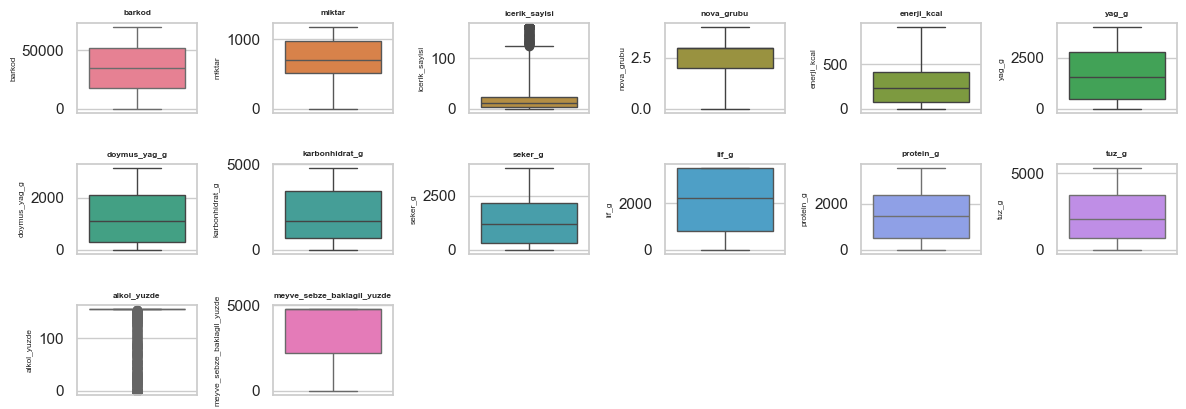

In [86]:
from sklearn.calibration import LabelEncoder
import seaborn as sns

veri = data.copy()

selected_columns = veri.select_dtypes(include=['number']).columns.tolist()

label_encoder = LabelEncoder()

for column in selected_columns:
    veri[column] = label_encoder.fit_transform(veri[column])

# Plot sayısını belirleyip subplotları ayarlayalım
fig, axes = plt.subplots(nrows=int(np.ceil(len(selected_columns)/3)), ncols=6, figsize=(12, 1 * int(np.ceil(len(selected_columns)/2))))

# Renk paleti seçimi
palette = sns.color_palette("husl", len(selected_columns))

# Boxplotları çizelim
axes = axes.flatten()
for i, col in enumerate(selected_columns):
    sns.boxplot(y=col, data=veri, ax=axes[i], color=palette[i], whis=5)
    axes[i].set_title(f'{col}', fontsize=6, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col, fontsize=6)

# Kullanılmayan subplotları kaldıralım
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Grafik düzenini iyileştirelim
plt.tight_layout(pad=1.0, w_pad=1.0, h_pad=2.0)
plt.show()

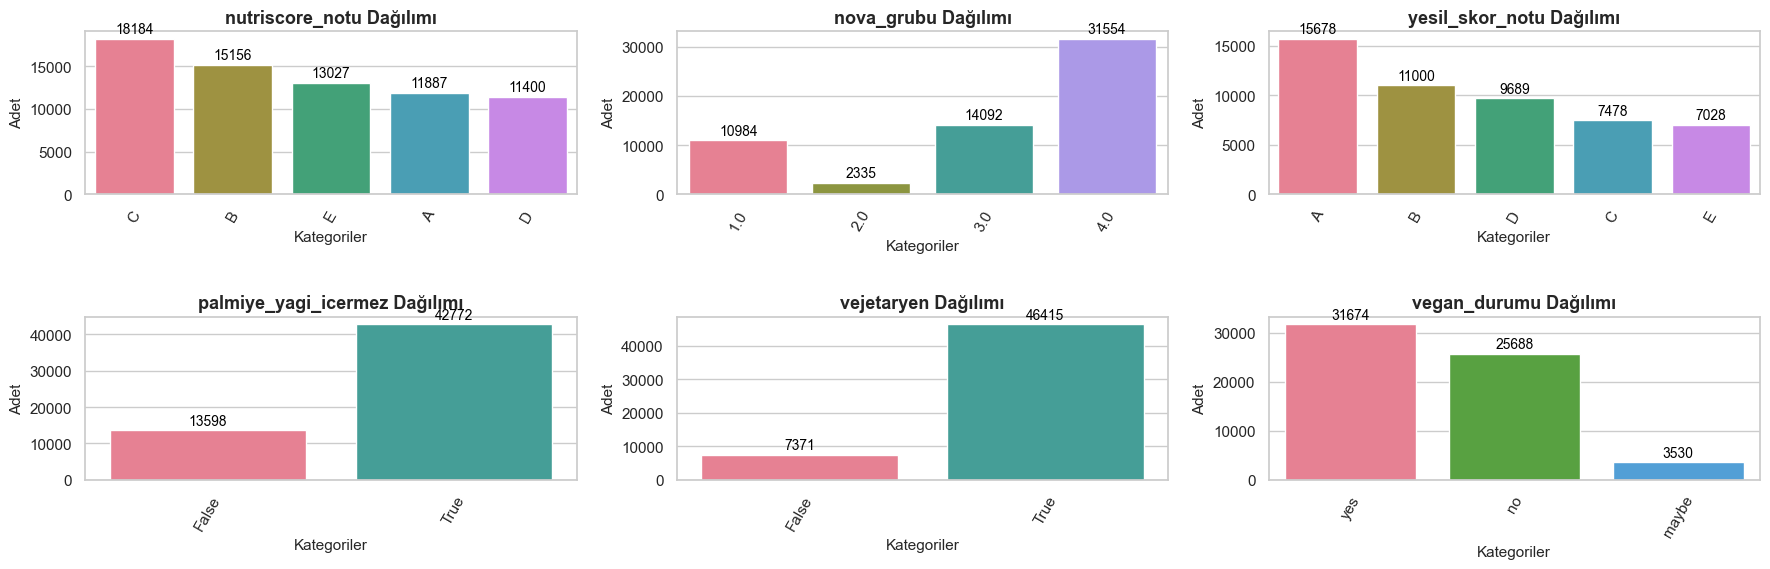

In [87]:
unique_counts = data.nunique()

categorical_columns = unique_counts[unique_counts <= 20].index.tolist()

n_cols = 3
n_rows = int(np.ceil(len(categorical_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*3))
axes = axes.flatten()

for i, column in enumerate(categorical_columns):
    val_counts = data[column].value_counts()
    sns.barplot(x=val_counts.index, y=val_counts.values, ax=axes[i], palette='husl')
    axes[i].set_title(f'{column} Dağılımı', fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Kategoriler", fontsize=11)
    axes[i].set_ylabel("Adet", fontsize=11)
    axes[i].tick_params(axis='x', rotation=60)

    # Her sütunun üzerine değerleri ekleyelim
    for p in axes[i].patches:
        axes[i].annotate(format(p.get_height(), '.0f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', fontsize=10, color='black', xytext=(0, 7),
                         textcoords='offset points')

# Kullanılmayan subplotları kaldıralım
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=1.5, w_pad=1.5, h_pad=2.5)
plt.show()


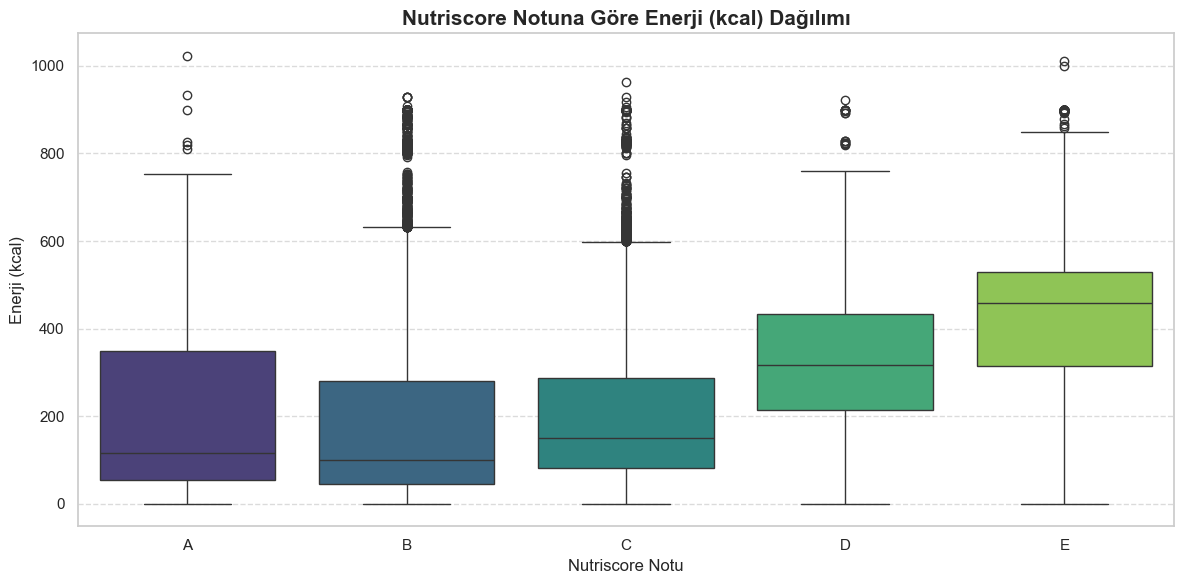

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi hazırlayalım
df_plot = data[['enerji_kcal', 'nutriscore_notu']].dropna()

# --- UÇ DEĞERLERİ TEMİZLEME (IQR YÖNTEMİ) ---
Q1 = df_plot['enerji_kcal'].quantile(0.20)
Q3 = df_plot['enerji_kcal'].quantile(0.80)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Sınırlar dışında kalan verileri temizleyelim
df_filtered = df_plot[(df_plot['enerji_kcal'] >= lower_bound) & (df_plot['enerji_kcal'] <= upper_bound)]
# ---------------------------------------------

# Nutriscore notlarını sıralı bir şekilde göstermek için liste tanımlayalım
nutriscore_order = ['A', 'B', 'C', 'D', 'E']

# Eğer veri setinizde bazı harfler yoksa mevcut olanları filtreleyelim
existing_scores = [score for score in nutriscore_order if score in df_filtered['nutriscore_notu'].unique()]

plt.figure(figsize=(12, 6))

# Boxplot çizimi (Temizlenmiş veri ile)
sns.boxplot(
    x='nutriscore_notu', 
    y='enerji_kcal', 
    data=df_filtered, 
    order=existing_scores, 
    palette='viridis'
)

# Grafik detayları
plt.title('Nutriscore Notuna Göre Enerji (kcal) Dağılımı', fontsize=15, fontweight='bold')
plt.xlabel('Nutriscore Notu', fontsize=12)
plt.ylabel('Enerji (kcal)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Grafiği gösterme
plt.tight_layout()
plt.show()

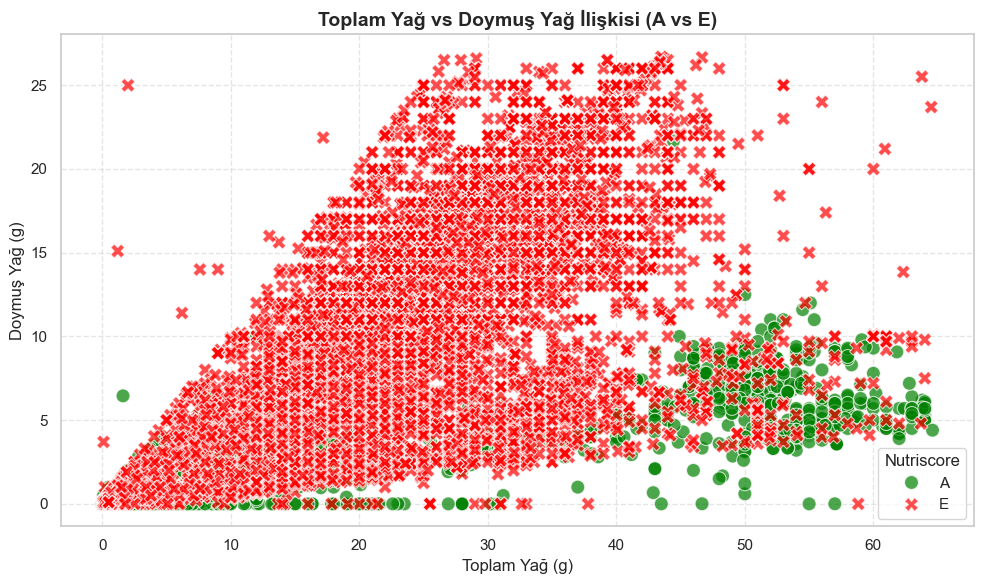

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi hazırlayalım
# Sadece 'A' ve 'E' olanları seçmek için isin() metodunu kullanıyoruz
df_clean = data.dropna(subset=['yag_g', 'doymus_yag_g', 'nutriscore_notu'])
df_clean = df_clean[(df_clean['yag_g'] > 0) & (df_clean['nutriscore_notu'].isin(['A', 'E']))].copy()

# 2. UÇ DEĞERLERİ TEMİZLEME (IQR YÖNTEMİ)
# Her iki sütun için de sınırlar belirleyip filtreleyelim
for col in ['yag_g', 'doymus_yag_g']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Sınırların dışındaki verileri eleyelim
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

# 3. Görselleştirme
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean, 
    x='yag_g', 
    y='doymus_yag_g', 
    hue='nutriscore_notu', 
    hue_order=['A', 'E'], # Sadece A ve E'yi göster
    palette={'A': 'green', 'E': 'red'}, # A yeşil, E kırmızı olsun
    style='nutriscore_notu',
    s=100, # Nokta boyutu
    alpha=0.7
)

plt.title('Toplam Yağ vs Doymuş Yağ İlişkisi (A vs E)', fontsize=14, fontweight='bold')
plt.xlabel('Toplam Yağ (g)')
plt.ylabel('Doymuş Yağ (g)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Nutriscore')
plt.tight_layout()
plt.show()

Text(0.5, 0.92, 'Temizlenmiş 3D Besin Değerleri Dağılımı (A vs E)')

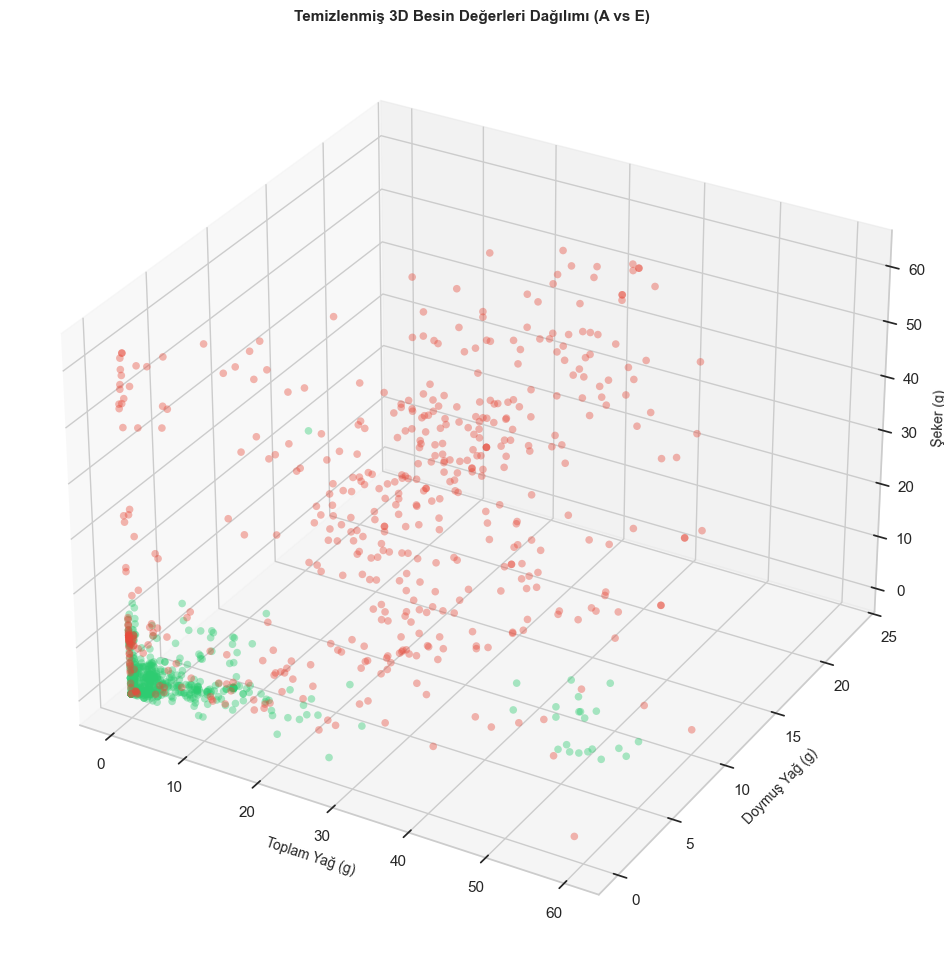

In [90]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# 1. Veriyi hazırlayalım
df_3d = data.dropna(subset=['yag_g', 'doymus_yag_g', 'seker_g', 'nutriscore_notu'])
# Sadece A ve E'yi seç
df_3d = df_3d[df_3d['nutriscore_notu'].isin(['A', 'E'])].copy()

# 2. UÇ DEĞERLERİ TEMİZLEME (IQR)
for col in ['yag_g', 'doymus_yag_g', 'seker_g']:
    Q1 = df_3d[col].quantile(0.25)
    Q3 = df_3d[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_3d = df_3d[(df_3d[col] >= lower_bound) & (df_3d[col] <= upper_bound)]

# --- [TEMİZLİK ADIMI]: ÖRNEKLEME (SAMPLING) ---
# Eğer veri hala çok yoğunsa, nokta sayısını azaltalım.
# max_points_per_group = 500 (Her grup için maksimum nokta)
num_A = min(len(df_3d[df_3d['nutriscore_notu'] == 'A']), 500)
num_E = min(len(df_3d[df_3d['nutriscore_notu'] == 'E']), 500)

df_sampled_A = df_3d[df_3d['nutriscore_notu'] == 'A'].sample(n=num_A, random_state=42)
df_sampled_E = df_3d[df_3d['nutriscore_notu'] == 'E'].sample(n=num_E, random_state=42)

# Temizlenmiş ve örneklenmiş veri seti
df_final = pd.concat([df_sampled_A, df_sampled_E])

# 3. Görselleştirme (Temizlenmiş Stille)
sns.set_style("whitegrid") # Beyaz grid arka plan
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Renkler: Daha soft (yumuşak) yeşil ve kırmızı tonları
colors = {'A': '#2ecc71', 'E': '#e74c3c'}

for score in ['A', 'E']:
    subset = df_final[df_final['nutriscore_notu'] == score]
    ax.scatter(
        subset['yag_g'], 
        subset['doymus_yag_g'], 
        subset['seker_g'], 
        c=colors[score], 
        label=f'Nutriscore {score}',
        s=30,      # Daha küçük nokta boyutu
        alpha=0.4, # Daha yüksek şeffaflık (arka arkaya gelenler yormasın)
        edgecolors='none' # Kenar çizgilerini kaldırdık
    )

# Eksen etiketleri ve görünüm ayarları
ax.set_xlabel('Toplam Yağ (g)', fontsize=10)
ax.set_ylabel('Doymuş Yağ (g)', fontsize=10)
ax.set_zlabel('Şeker (g)', fontsize=10)
ax.set_title('Temizlenmiş 3D Besin Değerleri Dağılımı (A vs E)', fontsize=11, fontweight='bold')

# Bakış açısını değiştirerek karmaşayı azaltabiliriz (isteğe bağlı)
# ax.view_init(elev=20, azim=135) # Yükseklik ve A


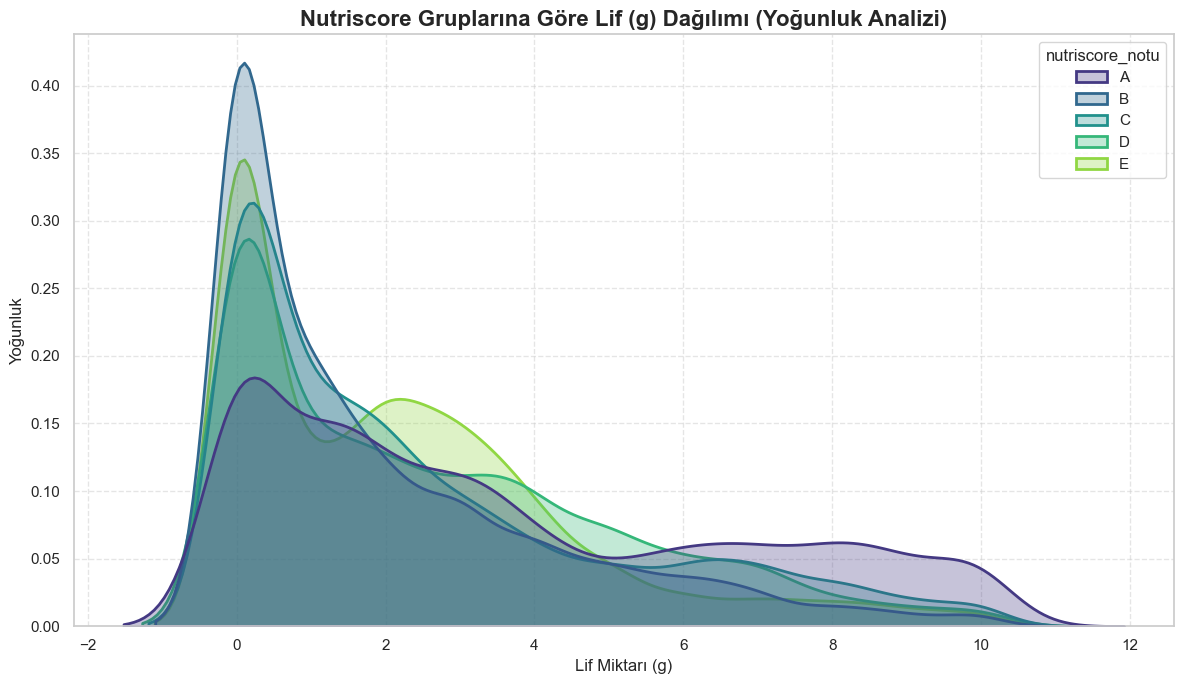

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi hazırlayalım
df_fiber = data[['lif_g', 'nutriscore_notu']].dropna()

# --- UÇ DEĞERLERİ TEMİZLEME (IQR YÖNTEMİ) ---
# Grafiğin daha düzgün gözükmesi için aşırı yüksek lif değerlerini temizleyelim
Q1 = df_fiber['lif_g'].quantile(0.25)
Q3 = df_fiber['lif_g'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df_fiber[(df_fiber['lif_g'] >= lower_bound) & (df_fiber['lif_g'] <= upper_bound)]

# Nutriscore sıralaması
nutriscore_order = ['A', 'B', 'C', 'D', 'E']

plt.figure(figsize=(12, 7))

# Yoğunluk (KDE) Grafiği
# common_norm=False: Her grubun kendi içindeki dağılımını daha net gösterir
sns.kdeplot(
    data=df_filtered, 
    x='lif_g', 
    hue='nutriscore_notu', 
    hue_order=nutriscore_order,
    fill=True, 
    alpha=0.3, # Şeffaflık
    linewidth=2,
    palette='viridis',
    common_norm=False
)

# Grafik detayları
plt.title('Nutriscore Gruplarına Göre Lif (g) Dağılımı (Yoğunluk Analizi)', fontsize=16, fontweight='bold')
plt.xlabel('Lif Miktarı (g)', fontsize=12)
plt.ylabel('Yoğunluk', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

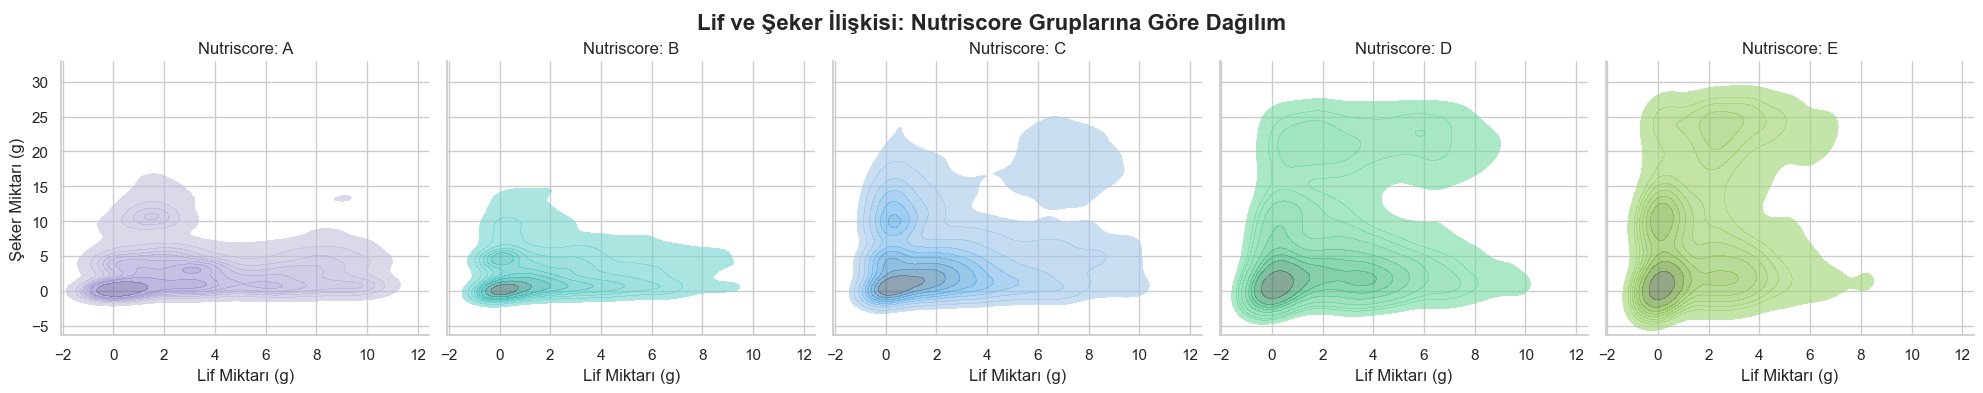

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi hazırlayalım
df_density = data.dropna(subset=['lif_g', 'seker_g', 'nutriscore_notu'])

# 2. UÇ DEĞERLERİ TEMİZLEME (IQR YÖNTEMİ)
# Lif ve Şeker için ayrı ayrı temizlik yapalım
for col in ['lif_g', 'seker_g']:
    Q1 = df_density[col].quantile(0.25)
    Q3 = df_density[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_density = df_density[(df_density[col] >= lower_bound) & (df_density[col] <= upper_bound)]

# 3. Görselleştirme (FacetGrid ile 2D Yoğunluk Haritası)
# Her Nutriscore grubu için ayrı bir "yoğunluk alanı" oluşturuyoruz
g = sns.FacetGrid(df_density, col="nutriscore_notu", col_order=['A', 'B', 'C', 'D', 'E'], 
                  hue="nutriscore_notu", palette="viridis", height=4, aspect=1)

# 2D KDE (Yoğunluk) grafiğini çiz
g.map_dataframe(sns.kdeplot, x="lif_g", y="seker_g", fill=True, alpha=0.6, thresh=0.05)

# 4. Profesyonel düzenlemeler
g.set_titles("Nutriscore: {col_name}")
g.set_axis_labels("Lif Miktarı (g)", "Şeker Miktarı (g)")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Lif ve Şeker İlişkisi: Nutriscore Gruplarına Göre Dağılım', fontsize=16, fontweight='bold')

plt.show()

In [93]:
data["kategori_listesi"].head(10)

0    ['Dairies', 'Fermented foods', 'Fermented milk...
1    ['Beverages and beverages preparations', 'Beve...
2    ['Beverages and beverages preparations', 'Beve...
3    ['Beverages and beverages preparations', 'Beve...
4    ['Beverages and beverages preparations', 'Beve...
5    ['Beverages and beverages preparations', 'Beve...
6    ['Beverages and beverages preparations', 'Beve...
7    ['Dairies', 'Fermented foods', 'Fermented milk...
8    ['Beverages and beverages preparations', 'Beve...
9    ['Dairies', 'Fermented foods', 'Fermented milk...
Name: kategori_listesi, dtype: object

In [94]:
# Kategori isimlerini Türkçe / açıklamalı hale getir

kategori_map = {
    "Sweet snacks": "Tatlı Atıştırmalıklar",
    "Snacks": "Atıştırmalıklar",
    "Dairies": "Süt Ürünleri",
    "Beverages": "İçecekler",
    "Fermented milk products": "Fermente Süt Ürünleri",
    "Fermented foods": "Fermente Gıdalar",
    "Cereals and potatoes": "Tahıllar ve Patates",
    "Plant-based foods and beverages": "Bitkisel Gıdalar ve İçecekler",
    "Plant-based foods": "Bitkisel Gıdalar",
    "Cereals and their products": "Tahıllar ve Tahıl Ürünleri"
}
top_kategoriler = df["kategori"].value_counts().head(10).index
mean_scores = (
    df[df["kategori"].isin(top_kategoriler)]
    .groupby("kategori")["score_num"]
    .mean()
    .sort_values()
)


# mean_scores indexlerini değiştir
mean_scores_tr = mean_scores.copy()
mean_scores_tr.index = mean_scores_tr.index.map(
    lambda x: kategori_map[x] if x in kategori_map else x
)

# Grafik
plt.figure(figsize=(14,7))

sns.barplot(
    x=mean_scores_tr.values,
    y=mean_scores_tr.index,
    palette="RdYlGn"
)

plt.title("En Sık 5 Kategorinin Ortalama NutriScore'u", fontsize=15)
plt.xlabel("Ortalama Skor (1 = E kötü, 5 = A iyi)")
plt.ylabel("Kategori")

# skor yazıları
for i, v in enumerate(mean_scores_tr.values):
    plt.text(v + 0.03, i, round(v,2), va="center", fontsize=11)

plt.xlim(1,5)
plt.tight_layout()
plt.show()

KeyError: 'kategori'